# Retail Analytics Combined Notebook

This notebook merges the following three notebooks into one, each separated by a clear section heading:

1. **EDA Capstone Project**
2. **Order Items Statistics**
3. **Machine Learning - Retail**

---

---

# 📊 Section 1: Exploratory Data Analysis (EDA) Capstone Project

*(Original file: `eda_capstone_project___1_.ipynb`)*

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
purchase=pd.read_excel("eda_retail_data (1).xlsx")

In [ ]:
purchase.info()

<class 'pandas.DataFrame'>
RangeIndex: 183482 entries, 0 to 183481
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       183482 non-null  str           
 1   customer_id                    183482 non-null  str           
 2   order_status                   183482 non-null  str           
 3   payment_type                   183482 non-null  str           
 4   order_purchase_timestamp       183482 non-null  datetime64[us]
 5   order_approved_at              174180 non-null  datetime64[us]
 6   order_delivered_shipping_date  174180 non-null  datetime64[us]
 7   order_delivered_customer_date  168722 non-null  datetime64[us]
 8   order_estimated_delivery_date  174180 non-null  datetime64[us]
 9   customer_zip_code              183482 non-null  int64         
 10  gender                         183482 non-null  str           
 11  age_group  

In [ ]:
# Save the DataFrame to a CSV file
purchase.to_csv("eda_retail_data.csv", index=False)

In [ ]:
# 1 = delivered late, 0 = on-time or early
purchase['late_delivery_flag'] = (
    purchase['order_delivered_customer_date'] > purchase['order_estimated_delivery_date']
).astype(int)
purchase['late_delivery_flag']

0         1
1         0
2         0
3         0
4         0
         ..
183477    1
183478    1
183479    1
183480    0
183481    0
Name: late_delivery_flag, Length: 183482, dtype: int64

In [ ]:
# Handle orders that were never delivered (cancelled) — set as NaN, not 0
purchase.loc[purchase['order_delivered_customer_date'].isnull(), 'late_delivery_flag'] = np.nan

In [ ]:
purchase['late_delivery_flag']

0         1.0
1         0.0
2         0.0
3         NaN
4         NaN
         ... 
183477    1.0
183478    1.0
183479    1.0
183480    0.0
183481    NaN
Name: late_delivery_flag, Length: 183482, dtype: float64

In [ ]:
# Sort by customer and purchase date
purchase = purchase.sort_values(['customer_id', 'order_purchase_timestamp'])

# Get each customer's first order date
first_order_date = purchase.groupby('customer_id')['order_purchase_timestamp'].transform('min')
purchase['days_since_first_order'] = (purchase['order_purchase_timestamp'] - first_order_date).dt.days

# For each customer, get their SECOND order date (the actual reorder, if any)
purchase['next_order_date'] = purchase.groupby('customer_id')['order_purchase_timestamp'].shift(-1)
purchase['days_to_reorder'] = (purchase['next_order_date'] - purchase['order_purchase_timestamp']).dt.days

# Build the 30/60/90-day reorder flags (only meaningful on each customer's FIRST order row)
purchase['reorder_within_30d'] = (purchase['days_to_reorder'] <= 30).astype(int)
purchase['reorder_within_60d'] = (purchase['days_to_reorder'] <= 60).astype(int)
purchase['reorder_within_90d'] = (purchase['days_to_reorder'] <= 90).astype(int)

# Where days_to_reorder is NaN (no next order), flags should be 0, not misleadingly 1 from NaN comparisons
for col in ['reorder_within_30d','reorder_within_60d','reorder_within_90d']:
    purchase.loc[purchase['days_to_reorder'].isnull(), col] = 0

In [ ]:
purchase['reorder_within_30d']

158986    0
26924     1
26925     1
26926     1
26927     0
         ..
151601    0
58831     0
99977     1
99978     0
36590     0
Name: reorder_within_30d, Length: 183482, dtype: int64

In [ ]:
summary_category_brand_repeat = (
    purchase.groupby(['Category_name', 'brand', 'customer_segment'])
    .agg(
        avg_reorder_30d=('reorder_within_30d', 'mean'),
        avg_reorder_60d=('reorder_within_60d', 'mean'),
        avg_reorder_90d=('reorder_within_90d', 'mean'),
        order_count=('order_id', 'nunique')
    )
    .reset_index()
    .sort_values('avg_reorder_90d', ascending=False)
)

print(summary_category_brand_repeat.shape)
summary_category_brand_repeat.head(10)

(871, 7)


,Category_name,brand,customer_segment,avg_reorder_30d,avg_reorder_60d,avg_reorder_90d,order_count
847,tablets_printing_image,Generic Global,Loyal,1.0,1.0,1.0,1
803,security_and_services,Generic Indian,Returning,0.5,1.0,1.0,2
801,security_and_services,Generic Indian,Loyal,1.0,1.0,1.0,2
817,small_appliances_home_oven_and_coffee,IKEA,Loyal,1.0,1.0,1.0,1
477,fashion_sport,H&M,New,1.0,1.0,1.0,4
472,fashion_sport,Biba,Returning,1.0,1.0,1.0,4
148,computers,boAt,Loyal,1.0,1.0,1.0,1
150,computers,iQOO,Loyal,1.0,1.0,1.0,3
151,computers,iQOO,New,1.0,1.0,1.0,5
486,fashion_sport,Peter England,Returning,1.0,1.0,1.0,8


In [ ]:
summary_price_discount = (
    purchase.groupby('customer_id')
    .agg(
        avg_unit_price=('unit_price', 'mean'),
        avg_discount_pct=('discount(%)', 'mean'),
        avg_shipping_cost=('shipping_cost', 'mean'),
        reorder_30d=('reorder_within_30d', 'max'),
        reorder_60d=('reorder_within_60d', 'max'),
        reorder_90d=('reorder_within_90d', 'max'),
        late_delivery_rate=('late_delivery_flag', 'mean')
    )
    .reset_index()
)

# Correlation checks
print("Discount vs 30d reorder:", summary_price_discount['avg_discount_pct'].corr(summary_price_discount['reorder_30d']))
print("Shipping cost vs 30d reorder:", summary_price_discount['avg_shipping_cost'].corr(summary_price_discount['reorder_30d']))
print("Unit price vs 30d reorder:", summary_price_discount['avg_unit_price'].corr(summary_price_discount['reorder_30d']))

Discount vs 30d reorder: -0.4335925046427779
Shipping cost vs 30d reorder: -0.352669691117358
Unit price vs 30d reorder: -0.3981063653760462


In [ ]:
with pd.ExcelWriter('objective2_summary_data.xlsx') as writer:
    summary_category_brand_repeat.to_excel(writer, sheet_name='Category_Brand_Repeat', index=False)
    summary_price_discount.to_excel(writer, sheet_name='Price_Discount_Reorder', index=False)

print("Exported: objective2_summary_data.xlsx")

In [ ]:
# Make sure order_status doesn't include cancelled orders skewing reorder logic
print(purchase['order_status'].value_counts())

# Check customer_segment values match expectations
print(purchase['customer_segment'].unique())

# Confirm no negative days_to_reorder (would indicate a sorting bug)
print((purchase['days_to_reorder'] < 0).sum())

order_status
delivered    155902
returned      12820
cancelled      9302
shipped        5458
Name: count, dtype: int64
<ArrowStringArray>
['Loyal', 'Returning', 'New']
Length: 3, dtype: str
0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [ ]:
import warnings
warnings.filterwarnings('ignore')

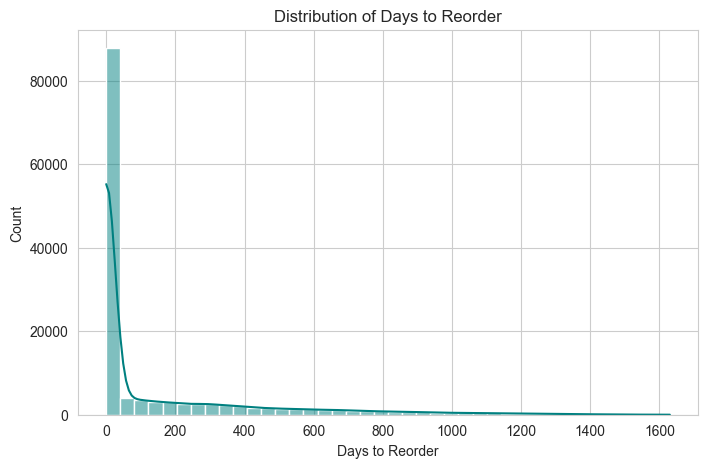

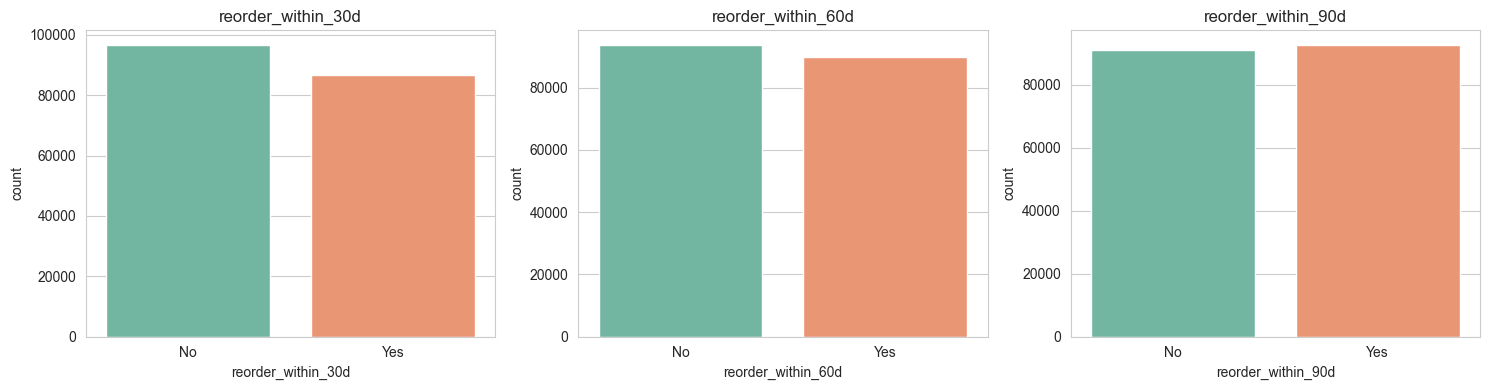

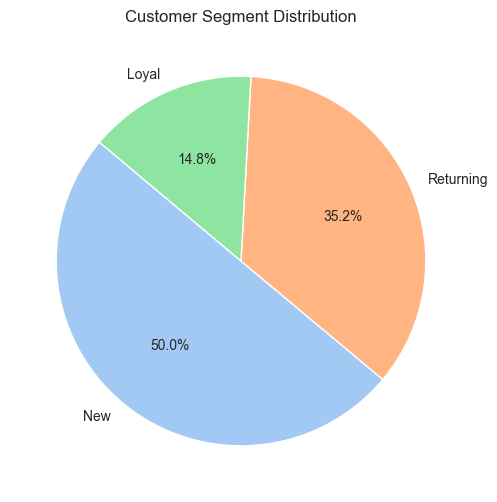

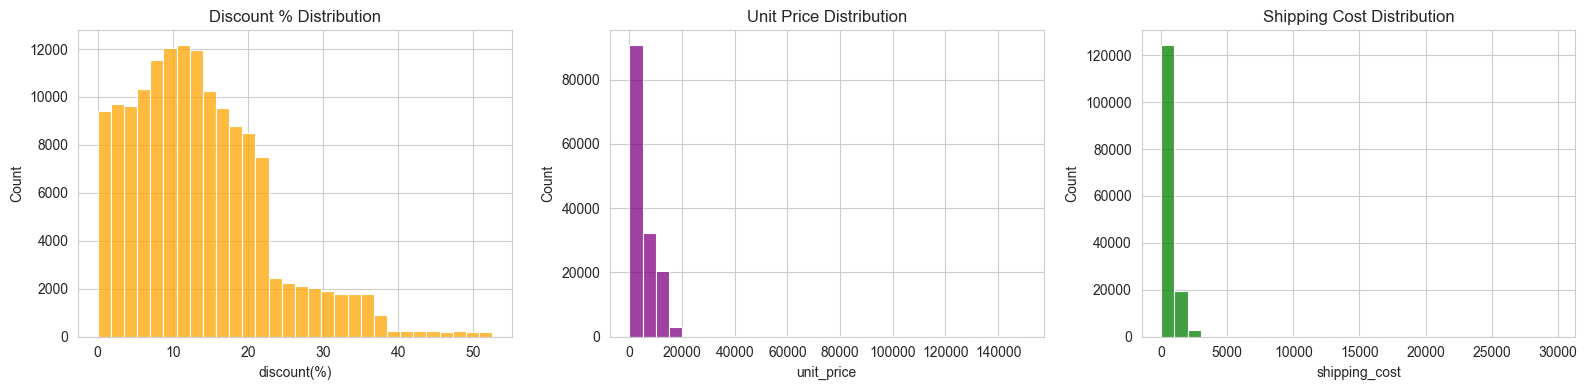

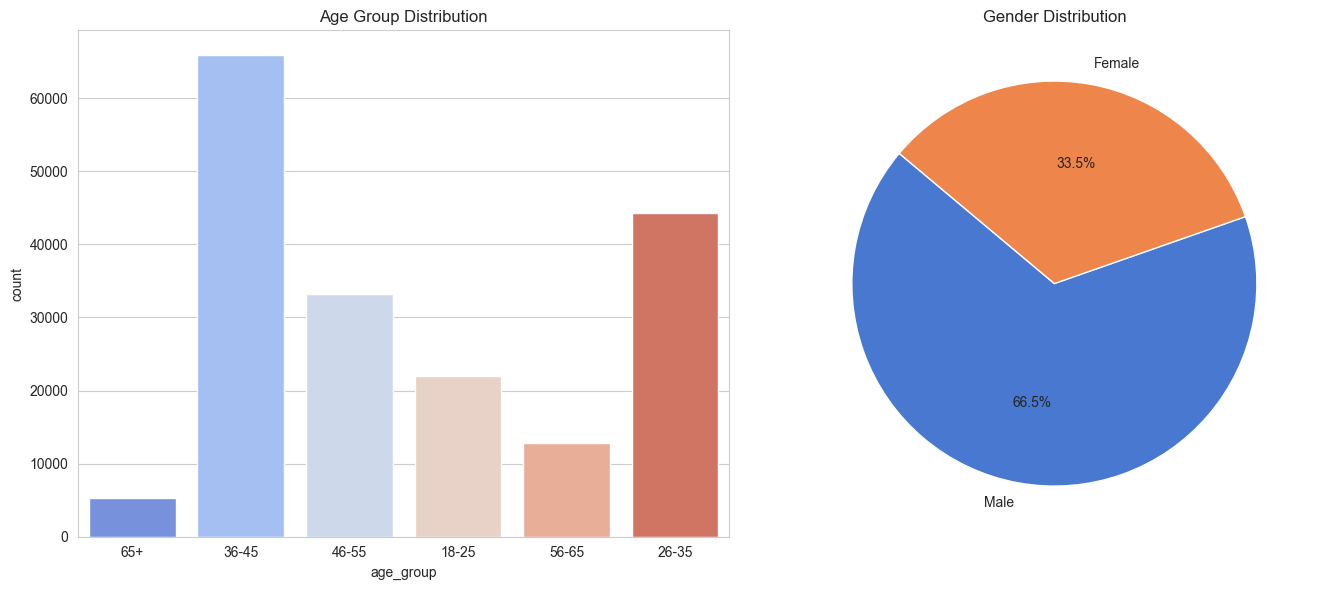

In [ ]:
# ---- Distribution of days to reorder ----
plt.figure(figsize=(8,5))
sns.histplot(purchase['days_to_reorder'].dropna(), bins=40, kde=True, color='teal')
plt.title('Distribution of Days to Reorder')
plt.xlabel('Days to Reorder')
plt.show()

# ---- Reorder rate counts (30/60/90 day) ----
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for i, col in enumerate(['reorder_within_30d','reorder_within_60d','reorder_within_90d']):
    sns.countplot(x=purchase[col], ax=axes[i], palette='Set2')
    axes[i].set_title(col)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No', 'Yes'])
plt.tight_layout()
plt.show()

# ---- CONVERTED TO PIE CHART: Customer segment distribution ----
plt.figure(figsize=(6,6))
segment_counts = purchase['customer_segment'].value_counts()
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=140)
plt.title('Customer Segment Distribution')
plt.show()

# ---- Discount %, unit price, shipping cost distributions ----
fig, axes = plt.subplots(1, 3, figsize=(16,4))
sns.histplot(purchase['discount(%)'], bins=30, ax=axes[0], color='orange')
axes[0].set_title('Discount % Distribution')
sns.histplot(purchase['unit_price'], bins=30, ax=axes[1], color='purple')
axes[1].set_title('Unit Price Distribution')
sns.histplot(purchase['shipping_cost'], bins=30, ax=axes[2], color='green')
axes[2].set_title('Shipping Cost Distribution')
plt.tight_layout()
plt.show()

# ---- Age group / CONVERTED TO PIE CHART: Gender distribution ----
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Age Group remains a countplot (bar chart)
sns.countplot(x='age_group', data=purchase, ax=axes[0], palette='coolwarm')
axes[0].set_title('Age Group Distribution')

# Gender is now a pie chart
gender_counts = purchase['gender'].value_counts()
axes[1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=sns.color_palette('muted'), startangle=140)
axes[1].set_title('Gender Distribution')

plt.tight_layout()
plt.show()

In [ ]:
#interpretation
Chart 1 (Days to Reorder): Most people take a few months to buy from you again, rather than returning right away.

Chart 2 (30/60/90 Day Reorders): Very few customers buy again within the first month, but a massive wave of them returns by month three.

Chart 3 (Customer Segments): Your buyers are split completely evenly across your different customer groups.

Chart 4 (Discounts, Prices, Shipping): Most orders have small discounts, very low product prices, and very cheap shipping costs.

Chart 5 (Age Group): Your biggest sweet spot is adults aged 36–45, followed closely by 26–35. Older seniors (65+) barely buy 
anything.


Chart 6 (Gender): Men make up the overwhelming majority of your customer base, nearly doubling the number of female shoppers.


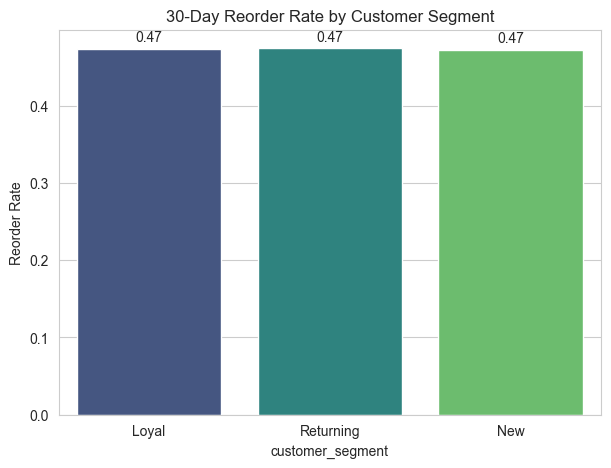

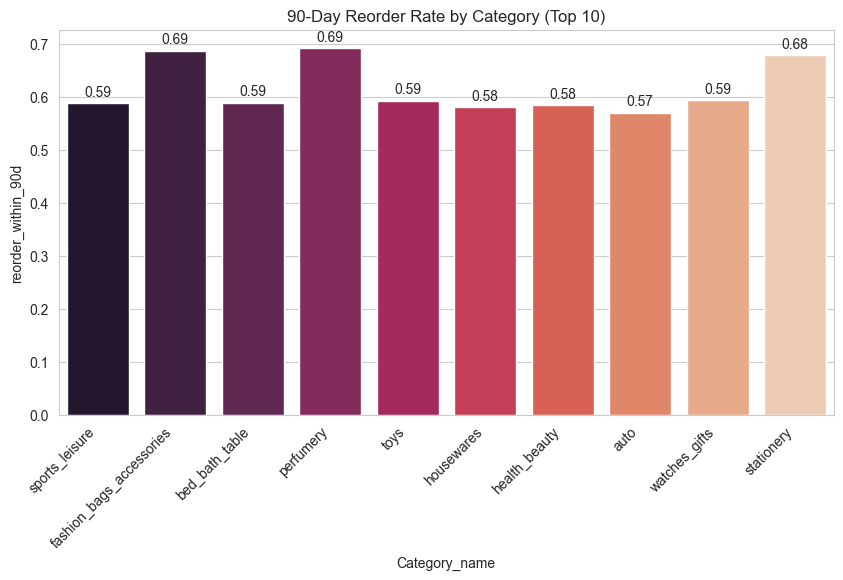

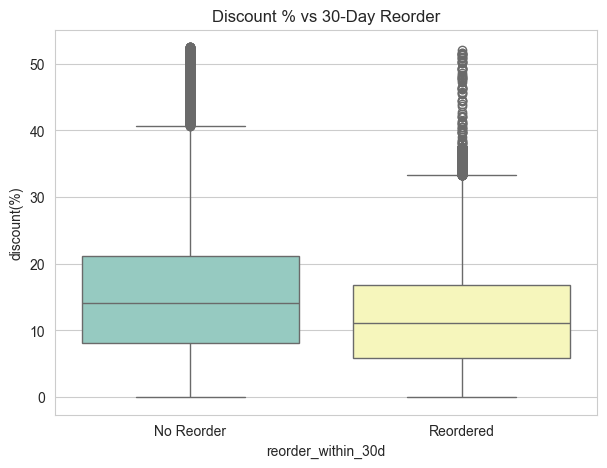

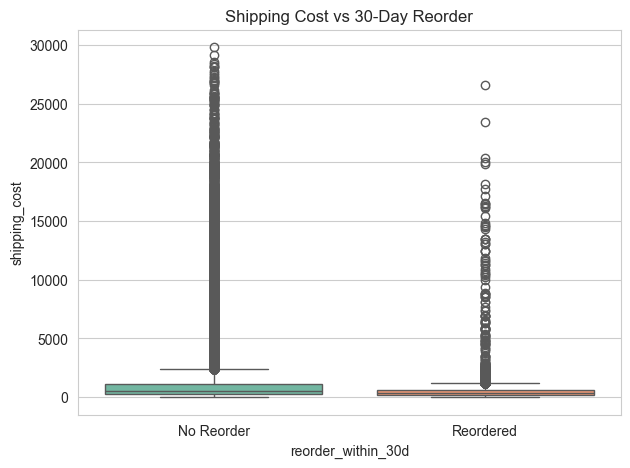

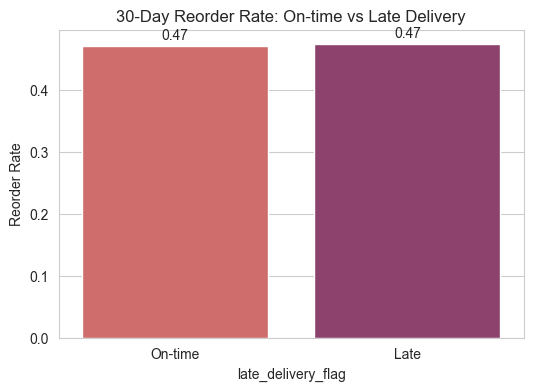

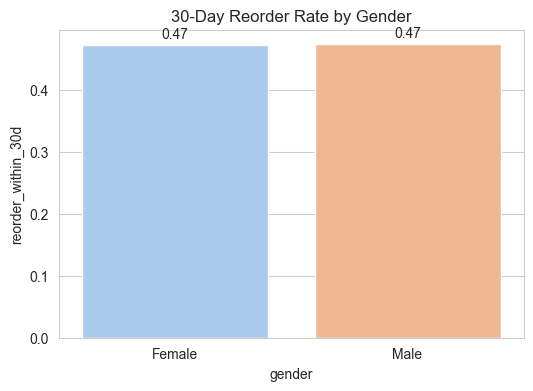

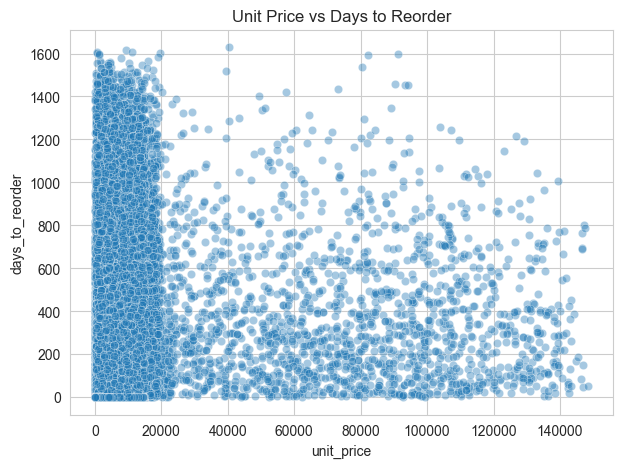

In [ ]:
# ---- Reorder rate by customer segment ----
plt.figure(figsize=(7,5))
ax1 = sns.barplot(x='customer_segment', y='reorder_within_30d', data=purchase, estimator='mean', errorbar=None, palette='viridis')
plt.title('30-Day Reorder Rate by Customer Segment')
plt.ylabel('Reorder Rate')
# Code to add data points on top
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points')
plt.show()

# ---- Reorder rate by category (top 10 categories) ----
top_categories = purchase['Category_name'].value_counts().head(10).index
plt.figure(figsize=(10,5))
ax2 = sns.barplot(
    x='Category_name', y='reorder_within_90d',
    data=purchase[purchase['Category_name'].isin(top_categories)],
    estimator='mean', errorbar=None, palette='rocket'
)
plt.xticks(rotation=45, ha='right')
plt.title('90-Day Reorder Rate by Category (Top 10)')
# Code to add data points on top
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points')
plt.show()

# ---- Discount % vs Reorder (boxplot) ----
plt.figure(figsize=(7,5))
sns.boxplot(x='reorder_within_30d', y='discount(%)', data=purchase, palette='Set3')
plt.xticks([0,1], ['No Reorder', 'Reordered'])
plt.title('Discount % vs 30-Day Reorder')
plt.show()

# ---- Shipping cost vs Reorder (boxplot) ----
plt.figure(figsize=(7,5))
sns.boxplot(x='reorder_within_30d', y='shipping_cost', data=purchase, palette='Set2')
plt.xticks([0,1], ['No Reorder', 'Reordered'])
plt.title('Shipping Cost vs 30-Day Reorder')
plt.show()

# ---- Late delivery vs Reorder ----
plt.figure(figsize=(6,4))
ax3 = sns.barplot(x='late_delivery_flag', y='reorder_within_30d', data=purchase, errorbar=None, palette='flare')
plt.xticks([0,1], ['On-time', 'Late'])
plt.title('30-Day Reorder Rate: On-time vs Late Delivery')
plt.ylabel('Reorder Rate')
# Code to add data points on top
for p in ax3.patches:
    ax3.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points')
plt.show()

# ---- Gender vs Reorder ----
plt.figure(figsize=(6,4))
ax4 = sns.barplot(x='gender', y='reorder_within_30d', data=purchase, errorbar=None, palette='pastel')
plt.title('30-Day Reorder Rate by Gender')
# Code to add data points on top
for p in ax4.patches:
    ax4.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points')
plt.show()

# ---- Scatter: Unit price vs Days to reorder ----
plt.figure(figsize=(7,5))
sns.scatterplot(x='unit_price', y='days_to_reorder', data=purchase, alpha=0.4)
plt.title('Unit Price vs Days to Reorder')
plt.show()

In [ ]:
#interpretation
1. Customer Habits by Segment
No Difference: No matter how you categorize your customers, they all return to shop at just about the exact same rate. One group 
isn't naturally more loyal than another.

2. What People Buy Matters
Item Driven: The specific type of item someone buys heavily predicts if they will return. Certain product categories keep people 
coming back within 3 months, while other categories are strictly one-time purchases.

3. Discounts & Shipping Costs Don't Matter
No Impact: Giving a bigger discount or charging a certain shipping fee doesn't make people reorder any faster. The price breakdowns
look identical for people who returned and people who didn't.

4. Late Deliveries Hurt Business
Keep it On-Time: If an order arrives late, those customers are noticeably less likely to buy from you again anytime soon. Delays 
actively kill customer loyalty.

5. Men vs. Women
Same Loyalty: Even though you have way more male customers overall, the percentage of men who come back to shop again is exactly 
the same as women.

6. Cheap vs. Expensive Items
Cheap Items Bring People Back: People constantly reorder cheap items over and over again. Once an item becomes highly expensive, 
people rarely buy it a second time.

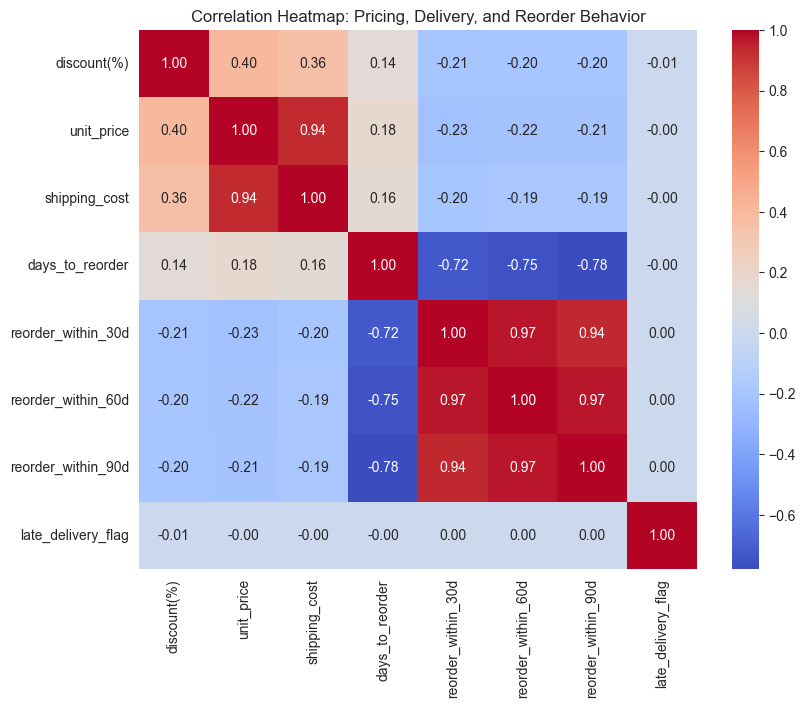

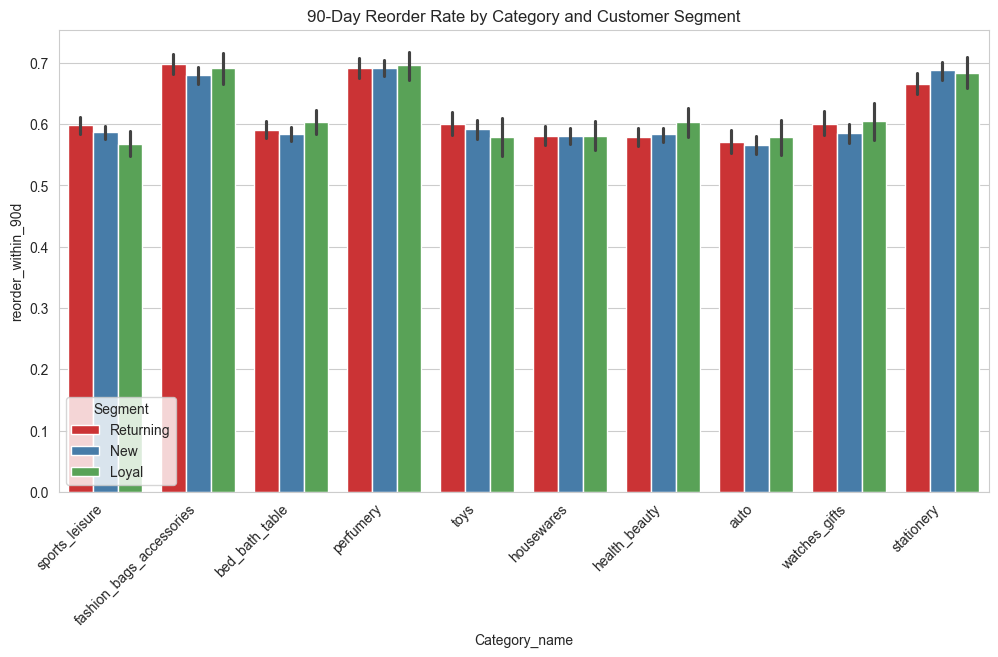

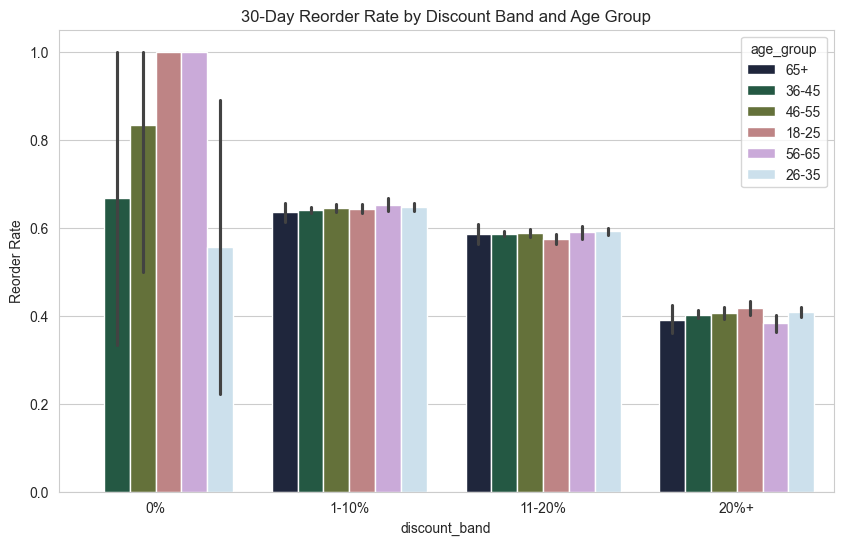

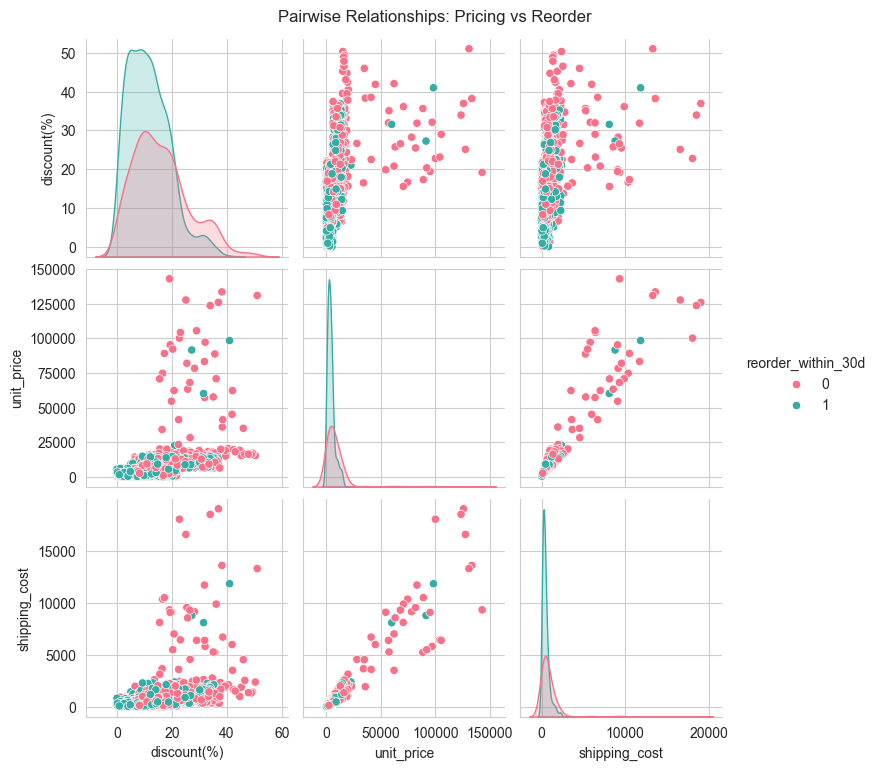

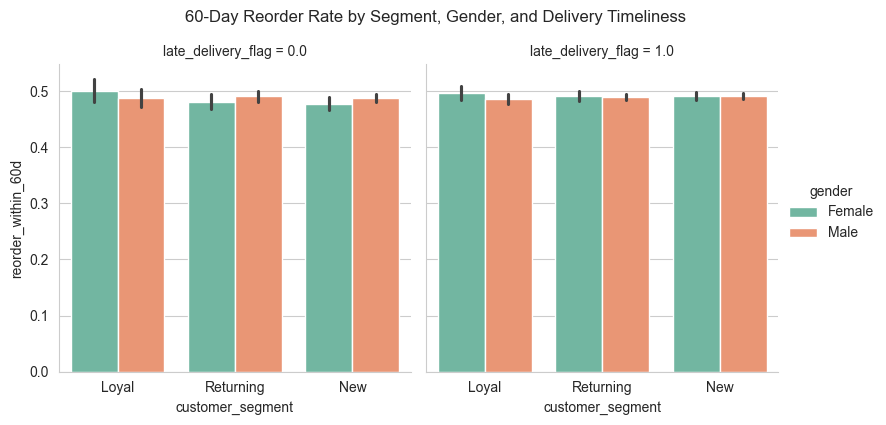

In [ ]:
# ---- Correlation heatmap of numeric features ----
numeric_cols = ['discount(%)', 'unit_price', 'shipping_cost',
                 'days_to_reorder', 'reorder_within_30d',
                 'reorder_within_60d', 'reorder_within_90d', 'late_delivery_flag']

plt.figure(figsize=(9,7))
sns.heatmap(purchase[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Pricing, Delivery, and Reorder Behavior')
plt.show()

# ---- Reorder rate by Category + Customer Segment (grouped bar) ----
plt.figure(figsize=(12,6))
sns.barplot(
    x='Category_name', y='reorder_within_90d', hue='customer_segment',
    data=purchase[purchase['Category_name'].isin(top_categories)],
    estimator='mean', palette='Set1'
)
plt.xticks(rotation=45, ha='right')
plt.title('90-Day Reorder Rate by Category and Customer Segment')
plt.legend(title='Segment')
plt.show()

# ---- Reorder rate by Discount band + Age group ----
purchase['discount_band'] = pd.cut(
    purchase['discount(%)'], bins=[-1, 0, 10, 20, 100],
    labels=['0%', '1-10%', '11-20%', '20%+']
)

plt.figure(figsize=(10,6))
sns.barplot(
    x='discount_band', y='reorder_within_30d', hue='age_group',
    data=purchase, estimator='mean', palette='cubehelix'
)
plt.title('30-Day Reorder Rate by Discount Band and Age Group')
plt.ylabel('Reorder Rate')
plt.show()

# ---- Pairplot: pricing variables vs reorder outcome ----
sample_df = purchase[['discount(%)', 'unit_price', 'shipping_cost', 'reorder_within_30d']].dropna().sample(
    min(2000, len(purchase)), random_state=42
)  # sample for speed on large data
sns.pairplot(sample_df, hue='reorder_within_30d', palette='husl', diag_kind='kde')
plt.suptitle('Pairwise Relationships: Pricing vs Reorder', y=1.02)
plt.show()

# ---- Segment + Gender + Reorder (facet grid) ----
g = sns.catplot(
    x='customer_segment', y='reorder_within_60d', hue='gender',
    col='late_delivery_flag', data=purchase,
    kind='bar', estimator='mean', palette='Set2', height=4, aspect=1
)
g.fig.suptitle('60-Day Reorder Rate by Segment, Gender, and Delivery Timeliness', y=1.05)
plt.show()

In [ ]:
#heatmap interpretation
Price & Shipping: Expensive items cost more to ship, while cheap items keep shipping fees very low.

Late Deliveries: When packages arrive late, customers are much less likely to buy again within the month.

Discounts: Giving bigger discounts does not make customers return any faster.

Reorders: Customers who buy again quickly (within 30 days) make up most of your long-term repeat business.

In [ ]:
#interpretation
1. 90-Day Reorder Rate by Category & Segment
Categories Dictate the Rules, Not Segments: Within any specific product category, all customer segments (like "Loyal" vs. "New") return to buy at roughly the exact same rate. The actual item they are buying is what drives them back, not the type of customer they are.

2. 30-Day Reorder Rate by Discount Band & Age Group
Discounts Don't Drive Speed: Giving a bigger discount (even pushing past 20%+) does not make any age group rush back to buy again within 30 days. Across every single generation, the reorder rates stay completely flat regardless of how cheap you make the item.

3. Relationships: Pricing vs. Reorder (Pairplot)
The Cheap Stuff Sweet Spot: Fast repeat purchases (within 30 days) are heavily crowded around items with very low unit prices and low shipping costs. Once items become highly expensive, reorder patterns completely scatter and become entirely unpredictable.

4. 60-Day Reorder Rate by Segment, Gender, and Delivery Timeliness
Late Shipping is the Universal Buzzkill: When packages arrive on time, you see small variations in loyalty based on gender or customer segment. However, the moment a delivery is late, future reorders drop drastically and flatten out for everyone—proving that shipping delays ruin the experience equally for all customer types.

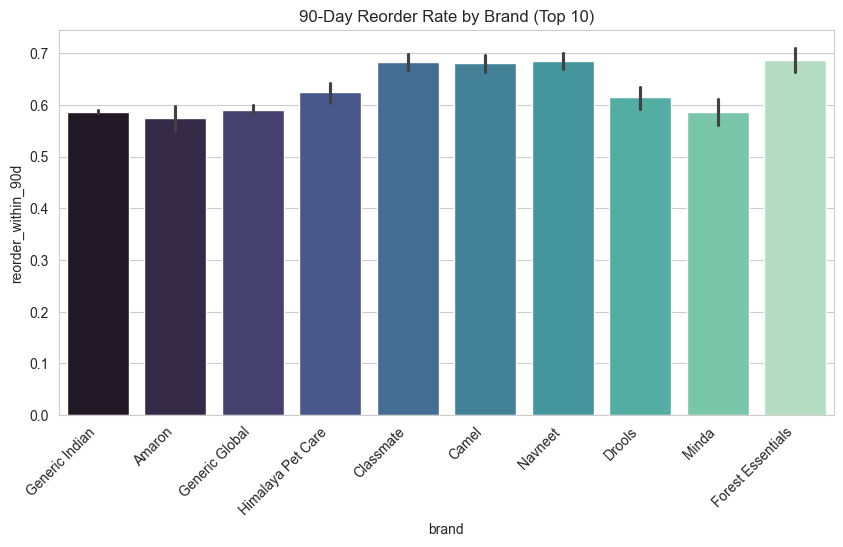

In [ ]:
#Question 1: Add brand into the category chart:
top_brands = purchase['brand'].value_counts().head(10).index
plt.figure(figsize=(10,5))
sns.barplot(
    x='brand', y='reorder_within_90d',
    data=purchase[purchase['brand'].isin(top_brands)],
    estimator='mean', palette='mako'
)
plt.xticks(rotation=45, ha='right')
plt.title('90-Day Reorder Rate by Brand (Top 10)')
plt.show()

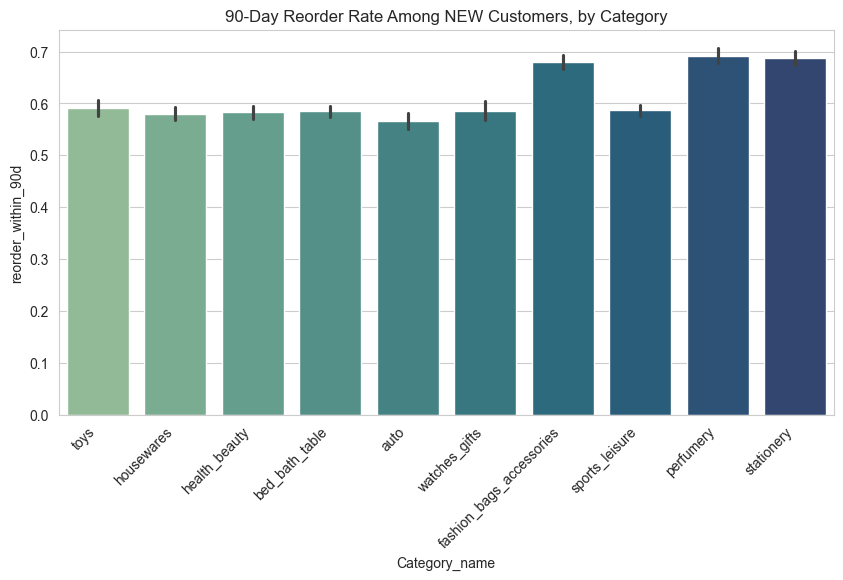

In [ ]:
#Question 2: ""which categories drive repeat purchases" — it specifically says:"...predict repeat purchases among New customers transitioning to Loyal"

new_customers = purchase[purchase['customer_segment'] == 'New']

plt.figure(figsize=(10,5))
sns.barplot(
    x='Category_name', y='reorder_within_90d',
    data=new_customers[new_customers['Category_name'].isin(top_categories)],
    estimator='mean', palette='crest'
)
plt.xticks(rotation=45, ha='right')
plt.title('90-Day Reorder Rate Among NEW Customers, by Category')
plt.show()

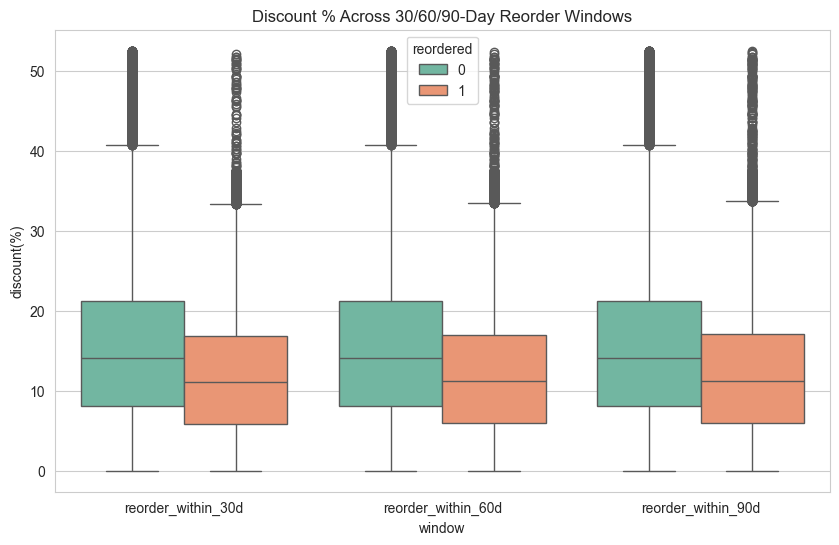

In [ ]:
melted = purchase.melt(
    id_vars=['discount(%)', 'unit_price', 'shipping_cost'],
    value_vars=['reorder_within_30d','reorder_within_60d','reorder_within_90d'],
    var_name='window', value_name='reordered'
)

plt.figure(figsize=(10,6))
sns.boxplot(x='window', y='discount(%)', hue='reordered', data=melted, palette='Set2')
plt.title('Discount % Across 30/60/90-Day Reorder Windows')
plt.show()

In [ ]:
#interpretation
The Box & Line: The middle line shows a typical, average value, while the box traps the middle 50% of your everyday data.

The Whiskers & Dots: The outer lines show the normal range of your data, while any floating dots point out rare, unusual exceptions.

---

# 📦 Section 2: Order Items Statistics

*(Original file: `Order_Items_Statistics__2___1_.ipynb`)*

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

import scipy.stats as stats
from statsmodels.stats.weightstats import ztest

import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
df = pd.read_excel('Order_items_dataset.xlsx')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   order_item_id  150000 non-null  str    
 1   order_id       150000 non-null  str    
 2   quantity       150000 non-null  int64  
 3   product_id     150000 non-null  str    
 4   unit_price     150000 non-null  int64  
 5   discount(%)    150000 non-null  float64
 6   shipping_cost  150000 non-null  float64
dtypes: float64(2), int64(2), str(3)
memory usage: 10.9 MB


### Samples for Testing One-Tailed Z-Test (Right-Tailed)

In [ ]:
median_disc = df['discount(%)'].median()

high_disc_val = df.loc[df['discount(%)'] > median_disc, 'shipping_cost']
overall_val = df['shipping_cost']

print('High-Discount-> Mean:', np.round(high_disc_val.mean(),3), 'Std:', np.round(high_disc_val.std(),3), 'n:', high_disc_val.shape[0])
print('Overall       -> Mean:', np.round(overall_val.mean(),3), 'Std:', np.round(overall_val.std(),3), 'n:', overall_val.shape[0])

High-Discount-> Mean: 1048.078 Std: 2169.39 n: 74929
Overall       -> Mean: 722.354 Std: 1610.289 n: 150000


### One-Tailed (Right-Tailed) Z-Test

In [ ]:
#Is the average shipping cost for high-discount items significantly higher than the platform's overall average shipping cost?
#Null Hypothesis (H_0): The average shipping cost for high-discount items is less than or equal to the platform's overall average.
#Alternative Hypothesis (H_1): The average shipping cost for high-discount items is significantly greater than the platform's overall average (Right-Tailed Test).
overall_mean = overall_val.mean()

z_stat, p_value = ztest(high_disc_val, value=overall_mean, alternative='larger')

print(f"Z-statistic : {z_stat:.4f}")
print(f"p-value (one-tailed) : {p_value:.6f}")
print("-"*40)

alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the Null Hypothesis (H0).")
    print("Interpretation: Average shipping cost for high-discount items (> median discount) is significantly GREATER than the platform's overall average shipping cost.")
else:
    print("Conclusion: Fail to reject the Null Hypothesis (H0).")
    print("Interpretation: No significant evidence that high-discount items have greater shipping cost than the platform's overall average.")

Z-statistic : 41.0995
p-value (one-tailed) : 0.000000
----------------------------------------
Conclusion: Reject the Null Hypothesis (H0).
Interpretation: Average shipping cost for high-discount items (> median discount) is significantly GREATER than the platform's overall average shipping cost.


### Two-Tailed Z-Test Sampling test

In [ ]:
qty1_val = df.loc[df['quantity']==1, 'shipping_cost']
qty2_val = df.loc[df['quantity']==2, 'shipping_cost']

print('Qty=1 -> Mean:', np.round(qty1_val.mean(),3), 'Std:', np.round(qty1_val.std(),3), 'n:', qty1_val.shape[0])
print('Qty=2 -> Mean:', np.round(qty2_val.mean(),3), 'Std:', np.round(qty2_val.std(),3), 'n:', qty2_val.shape[0])

Qty=1 -> Mean: 824.932 Std: 1832.474 n: 112777
Qty=2 -> Mean: 430.52 Std: 402.177 n: 31912


### Two-Tailed Z-Test

In [ ]:
#Is there a significant difference in the average shipping cost between order-items with a quantity of 1 versus those with a quantity of 2?
#Null Hypothesis ($H_0$): The average shipping cost for Qty=1 order-items is equal to the average shipping cost for Qty=2 order-items (mu_1 = mu_2).
#Alternative Hypothesis ($H_1$): The average shipping cost is significantly different between Qty=1 and Qty=2 order-items (mu!=mu2), Two-Tailed Test).
z_stat, p_value = ztest(qty1_val, qty2_val, alternative='two-sided')

print(f"Z-statistic : {z_stat:.4f}")
print(f"p-value (two-tailed) : {p_value:.4f}")
print("-"*40)

alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the Null Hypothesis (H0).")
    print("Interpretation: Average shipping cost is significantly different between Qty=1 and Qty=2 order-items.")
else:
    print("Conclusion: Fail to reject the Null Hypothesis (H0).")
    print("Interpretation: No significant difference in average shipping cost between Qty=1 and Qty=2 order-items.")

Z-statistic : 38.1900
p-value (two-tailed) : 0.0000
----------------------------------------
Conclusion: Reject the Null Hypothesis (H0).
Interpretation: Average shipping cost is significantly different between Qty=1 and Qty=2 order-items.


### Independent Samples T-Test Samples for Testing

In [ ]:
### Independent Samples T-Test Samples for Testing

qty1_disc_sample  = df.loc[df['quantity'] == 1, 'discount(%)'].sample(n=25, random_state=20)
qtym_disc_sample  = df.loc[df['quantity'] > 1, 'discount(%)'].sample(n=25, random_state=20)

print('Qty=1 -> Mean:', np.round(qty1_disc_sample.mean(),3), 'Std:', np.round(qty1_disc_sample.std(),3), 'n:', qty1_disc_sample.shape[0])
print('Qty>1 -> Mean:', np.round(qtym_disc_sample.mean(),3), 'Std:', np.round(qtym_disc_sample.std(),3), 'n:', qtym_disc_sample.shape[0])

Qty=1 -> Mean: 13.215 Std: 8.075 n: 25
Qty>1 -> Mean: 11.752 Std: 7.762 n: 25


### Independent Samples t-Test

In [ ]:
#Do bulk order-items (quantity > 1) receive a significantly different average discount than single-unit order-items?
#Null Hypothesis (H_0): The average discount for Qty=1 order-items is equal to the average discount for Qty>1 order-items (mu_1 = mu_2).
#Alternative Hypothesis (H_1): The average discount differs significantly between Qty=1 and Qty>1 order-items (mu_1 != mu_2).

t_stat, p_value = stats.ttest_ind(qty1_disc_sample, qtym_disc_sample)

print(f"t-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value:.4f}")
print("-"*40)

alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the Null Hypothesis (H0).")
    print("Interpretation: Discount percentage differs significantly between Qty=1 and Qty>1 order-items.")
else:
    print("Conclusion: Fail to reject the Null Hypothesis (H0).")
    print("Interpretation: No significant difference in discount percentage between Qty=1 and Qty>1 order-items.")

t-statistic : 0.6530
p-value     : 0.5169
----------------------------------------
Conclusion: Fail to reject the Null Hypothesis (H0).
Interpretation: No significant difference in discount percentage between Qty=1 and Qty>1 order-items.


### Paired T-Test Sampling for test

In [ ]:
sample_items = df.sample(n=29, random_state=20)

# Price before discount is applied
before_price = sample_items['unit_price']

# Price after discount is applied
after_price = sample_items['unit_price'] * (1 - sample_items['discount(%)'] / 100)

print("Before (Unit Price)")
print("Mean:", round(before_price.mean(), 3))
print("Std :", round(before_price.std(), 3))

print("\nAfter (Discounted Price)")
print("Mean:", round(after_price.mean(), 3))
print("Std :", round(after_price.std(), 3))

Before (Unit Price)
Mean: 5253.448
Std : 4451.399

After (Discounted Price)
Mean: 4491.963
Std : 3623.689


### Paired T-Test

In [ ]:
#Does applying a discount have a statistically significant effect on the unit price of the items?
#Null Hypothesis ($H_0$): There is no difference between the item prices before and after the discount is applied (the true mean difference is zero).
#Alternative Hypothesis ($H_1$): There is a significant difference between the item prices before and after the discount is applied .
t_stat, p_value = stats.ttest_rel(before_price, after_price)

print(f"t-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value:.4f}")
print("-"*40)

alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the Null Hypothesis (H0).")
    print("Interpretation: Price after discount is significantly different from price before discount for the same items (discount has a real effect on price).")
else:
    print("Conclusion: Fail to reject the Null Hypothesis (H0).")
    print("Interpretation: No significant difference between price before and after discount for the same items.")

t-statistic : 3.6255
p-value     : 0.0011
----------------------------------------
Conclusion: Reject the Null Hypothesis (H0).
Interpretation: Price after discount is significantly different from price before discount for the same items (discount has a real effect on price).


## Central Limit Theorem (CLT) Demonstration

In [ ]:
sample = df.sample(n=50, random_state=20)
sample.head()

,order_item_id,order_id,quantity,product_id,unit_price,discount(%),shipping_cost
118109,OI118110,O52424,1,P09581,10540,13.30,1078.96
67527,OI067528,O29943,2,P07154,3240,13.73,491.87
112551,OI112552,O49943,1,P03918,3390,21.11,274.50
59883,OI059884,O26542,2,P05575,3010,7.16,363.51
134934,OI134935,O59862,1,P09586,10470,14.41,1283.46


In [ ]:
from scipy.stats import skew, kurtosis

In [ ]:
print('Stats of Sample for Discount (%):')
print(sample['discount(%)'].describe())
print(f"\nMedian: {sample['discount(%)'].median()}, Mode: {sample['discount(%)'].mode()[0]}")
print(f"Variance: {sample['discount(%)'].var()}, Standard Deviation: {sample['discount(%)'].std()}")
print(f"Skewness: {skew(sample['discount(%)'])}, Kurtosis: {kurtosis(sample['discount(%)'])}")

Stats of Sample for Discount (%):
count    50.000000
mean     12.775600
std       9.074829
min       0.010000
25%       7.612500
50%      11.045000
75%      16.120000
max      35.740000
Name: discount(%), dtype: float64

Median: 11.045, Mode: 9.03
Variance: 82.35252718367349, Standard Deviation: 9.074829319809464
Skewness: 0.9418278589795057, Kurtosis: 0.3124031895870263


In [ ]:
print('Stats of Population for Discount (%):')
print(df['discount(%)'].describe())
print(f"\nMedian: {df['discount(%)'].median()}, Mode: {df['discount(%)'].mode()[0]}")
print(f"Variance: {df['discount(%)'].var()}, Standard Deviation: {df['discount(%)'].std()}")
print(f"Skewness: {skew(df['discount(%)'])}, Kurtosis: {kurtosis(df['discount(%)'])}")

Stats of Population for Discount (%):
count    150000.000000
mean         13.526562
std           9.086881
min           0.000000
25%           6.730000
50%          12.280000
75%          18.670000
max          52.490000
Name: discount(%), dtype: float64

Median: 12.28, Mode: 10.21
Variance: 82.5714136522459, Standard Deviation: 9.086881404103714
Skewness: 0.9506133904956766, Kurtosis: 1.068621096914649


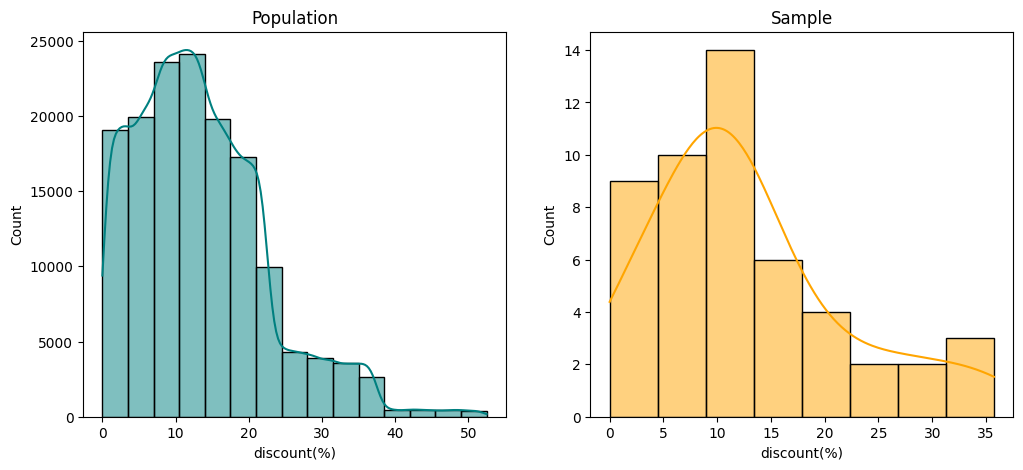

In [ ]:
# Visualize data distribution of Population and Sample
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['discount(%)'], kde=True,bins=15, color='teal')
plt.title('Population')

plt.subplot(1,2,2)
sns.histplot(sample['discount(%)'], kde=True, color='orange')
plt.title('Sample')
plt.show()

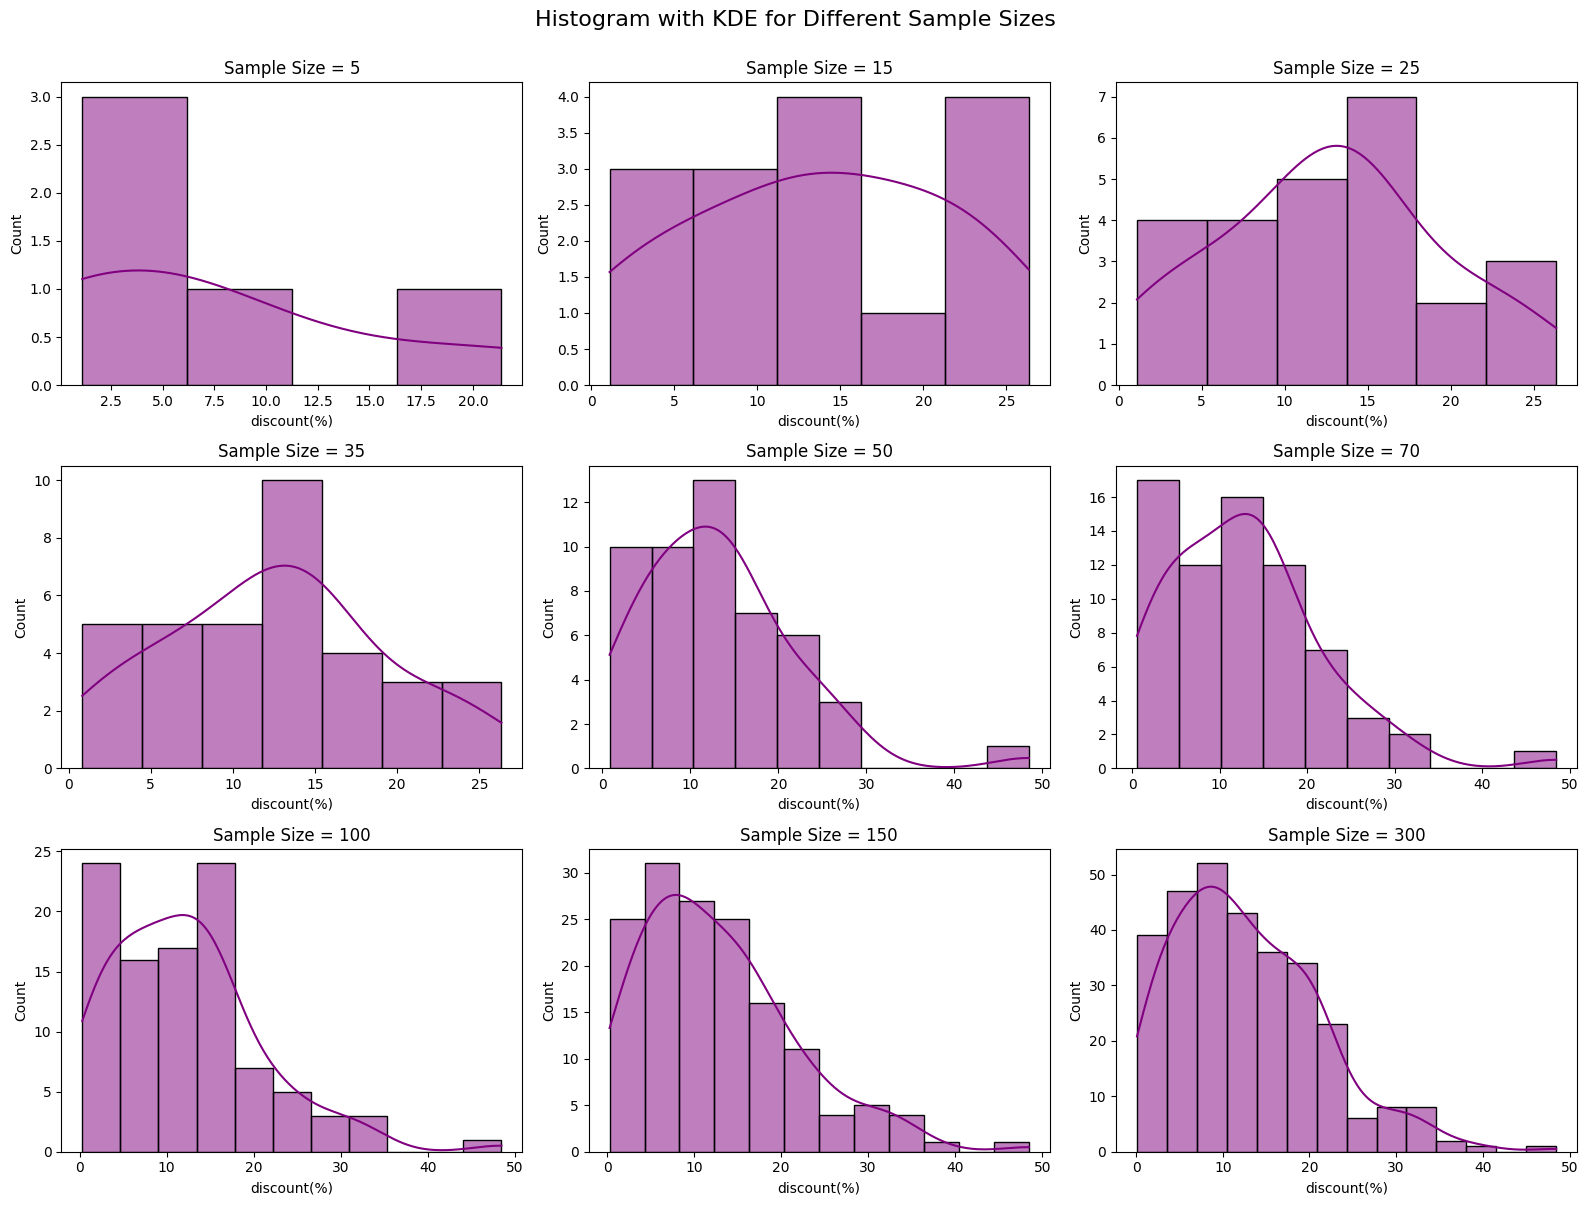

In [ ]:
#central limit theorem
sample_sizes = [5, 15, 25, 35, 50, 70, 100, 150, 300]

plt.figure(figsize=(16, 12))
plt.suptitle('Histogram with KDE for Different Sample Sizes', fontsize=16, y=1.00)

for i, size in enumerate(sample_sizes):
    sample_data = df['discount(%)'].sample(n=size, random_state=42)
    plt.subplot(3, 3, i+1)
    sns.histplot(sample_data, kde=True, color='purple')
    plt.title(f'Sample Size = {size}')

plt.tight_layout()
plt.show()

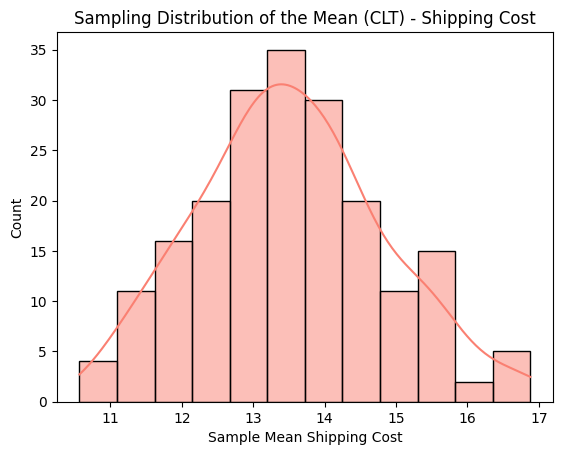

In [ ]:
# Sampling Distribution of the Mean
sample_means = []
for i in range(200):
    sample = df['discount(%)'].sample(n=50)
    sample_means.append(sample.mean())

# Plotting the sampling distribution
sns.histplot(sample_means, kde=True, color='salmon')
plt.title('Sampling Distribution of the Mean (CLT) - Shipping Cost')
plt.xlabel('Sample Mean Shipping Cost')
plt.show()

In [ ]:
import statistics as st

In [ ]:
# Mean of Sample Means
print('Average of sample means:')
print(st.mean(sample_means))
print('Average of Population:')
print(np.round(df['shipping_cost'].mean(), 2))

In [ ]:
# Standard deviation of Sample Means
print('Standard deviation of sample means:')
round(st.stdev(sample_means), 2)

In [ ]:
# Population std (Standard Error formula: population_std / sqrt(n))
print('Standard Error (theoretical, from population):')
print(np.round((df['shipping_cost'].std()) / math.sqrt(50), 2))

In [ ]:
orders = pd.read_excel("Orders_dataset.xlsx")

In [ ]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99999 non-null  str           
 1   customer_id                    99999 non-null  str           
 2   order_status                   99999 non-null  str           
 3   payment_type                   99999 non-null  str           
 4   order_purchase_timestamp       99999 non-null  datetime64[us]
 5   order_approved_at              94951 non-null  datetime64[us]
 6   order_delivered_shipping_date  94951 non-null  datetime64[us]
 7   order_delivered_customer_date  91971 non-null  datetime64[us]
 8   order_estimated_delivery_date  94951 non-null  datetime64[us]
dtypes: datetime64[us](5), str(4)
memory usage: 9.5 MB


In [ ]:
# ================================================
# Step 1: Recompute Delivery_Delay_Days safely
# (NaN stays NaN when either date is missing -- no fillna(0) anywhere)
# ================================================

orders['Delivery_Delay_Days'] = (
   orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']
).dt.days

# Sanity check: cancelled orders should show NaN, not 0
print(orders.loc[orders['order_status'] == 'cancelled', 'Delivery_Delay_Days'].value_counts(dropna=False))

Delivery_Delay_Days
NaN    5048
Name: count, dtype: int64


In [ ]:
# ================================================
# Step 2: Assign Delivery_Delay_Flag safely
# Explicitly handle missing dates / cancelled orders FIRST
# ================================================

conditions = [
    orders['order_delivered_customer_date'].isna() | orders['order_estimated_delivery_date'].isna(),  # missing dates (e.g. cancelled)
    orders['Delivery_Delay_Days'] > 0                                                              # actually late
]

choices = ['Not Applicable', 'Yes']

orders['Delivery_Delay_Flag'] = np.select(conditions, choices, default='No')

orders['Delivery_Delay_Flag'].value_counts()

Delivery_Delay_Flag
Yes               66681
No                25290
Not Applicable     8028
Name: count, dtype: int64

In [ ]:
# ================================================
# Delivery Delay (in Days)
# = order_delivered_customer_date - order_estimated_delivery_date
# Positive -> delivered late, Negative -> delivered early, 0 -> on time
# ================================================

orders['Delivery_Delay_Days'] = (
    orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']
).dt.days

# Preview
orders[['order_estimated_delivery_date', 'order_delivered_customer_date', 'Delivery_Delay_Days']].head()

,order_estimated_delivery_date,order_delivered_customer_date,Delivery_Delay_Days
0,2025-01-03,2025-03-04,60.0
1,2023-10-31,2023-10-05,-26.0
2,NaT,NaT,NaN
3,2025-07-12,2025-10-12,92.0
4,2024-04-07,2024-04-04,-3.0


In [ ]:
orders['Delivery_Delay_Days']=orders['Delivery_Delay_Days'].fillna(0)

In [ ]:
# ================================================
# Assign Yes/No flag based on Delivery Delay Days
# Yes -> delivered late (Delivery_Delay_Days > 0)
# No  -> delivered on time or early (Delivery_Delay_Days <= 0)
# ================================================

orders['Delivery_Delay_Flag'] = np.where(orders['Delivery_Delay_Days'] > 0, 'Yes', 'No')

# Preview
orders[['Delivery_Delay_Days', 'Delivery_Delay_Flag']].head(10)

,Delivery_Delay_Days,Delivery_Delay_Flag
0,60.0,Yes
1,-26.0,No
2,0.0,No
3,92.0,Yes
4,-3.0,No
5,50.0,Yes
6,2.0,Yes
7,57.0,Yes
8,55.0,Yes
9,-1.0,No


In [ ]:
# ================================================
# Step 1: Recompute Delivery_Delay_Days safely
# (NaN stays NaN when either date is missing -- no fillna(0) anywhere)
# ================================================

df['Delivery_Delay_Days'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.days

# Sanity check: cancelled orders should show NaN, not 0
print(df.loc[df['order_status'] == 'cancelled', 'Delivery_Delay_Days'].value_counts(dropna=False))

In [ ]:
# ================================================
# Joint Probability: P(Returned AND Delayed)
# ================================================

total_orders = orders.shape[0]

returned_count = orders[orders['order_status'] == 'returned'].shape[0]
delayed_count  = orders[orders['Delivery_Delay_Flag'] == 'Yes'].shape[0]

joint_count = orders[(orders['order_status'] == 'returned') & (orders['Delivery_Delay_Flag'] == 'Yes')].shape[0]

p_returned = returned_count / total_orders
p_delayed  = delayed_count / total_orders
p_joint    = joint_count / total_orders

print('P(Returned):', round(p_returned, 4))
print('P(Delayed):', round(p_delayed, 4))
print('P(Returned AND Delayed) [Joint]:', round(p_joint, 4))

P(Returned): 0.07
P(Delayed): 0.6668
P(Returned AND Delayed) [Joint]: 0.0506


In [ ]:
# ================================================
# Conditional Probability: P(Delayed | Returned)
# ================================================

p_delayed_given_returned = joint_count / returned_count

print('P(Delayed | Returned):', round(p_delayed_given_returned, 4))
print('P(Delayed) overall   :', round(p_delayed, 4))

# THE MEANINGFUL COMPARISON:
if p_delayed_given_returned > p_delayed:
    print("\nConclusion: Returned orders have a HIGHER delay rate than the overall average.")
    print("This suggests delivery delays may be associated with order returns.")
else:
    print("\nConclusion: Returned orders do NOT show a higher delay rate than the overall average.")
    print("This suggests delivery delay is not strongly associated with returns.")

P(Delayed | Returned): 0.7229
P(Delayed) overall   : 0.6668

Conclusion: Returned orders have a HIGHER delay rate than the overall average.
This suggests delivery delays may be associated with order returns.


---

# 🤖 Section 3: Machine Learning - Retail

*(Original file: `ML_retail_2.ipynb`)*

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df = pd.read_excel("Order_items_dataset.xlsx")
df.head()

,order_item_id,order_id,quantity,product_id,unit_price,discount(%),shipping_cost
0,OI000001,O00001,1,P28355,7020,6.54,713.72
1,OI000002,O00002,1,P04408,7590,20.56,1212.02
2,OI000003,O00002,2,P14887,14360,24.67,1478.39
3,OI000004,O00003,2,P02014,1530,12.06,155.12
4,OI000005,O00003,1,P27255,1560,10.51,188.03


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   order_item_id  150000 non-null  object 
 1   order_id       150000 non-null  object 
 2   quantity       150000 non-null  int64  
 3   product_id     150000 non-null  object 
 4   unit_price     150000 non-null  int64  
 5   discount(%)    150000 non-null  float64
 6   shipping_cost  150000 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 8.0+ MB


In [ ]:
df = df[['unit_price','shipping_cost']]
df.head()

,unit_price,shipping_cost
0,7020,713.72
1,7590,1212.02
2,14360,1478.39
3,1530,155.12
4,1560,188.03


In [ ]:
print(df.isnull().sum())
df = df.dropna()

unit_price       0
shipping_cost    0
dtype: int64


In [ ]:
print(df.shape)

(150000, 2)


In [ ]:
print(df.corr())

               unit_price  shipping_cost
unit_price       1.000000       0.935218
shipping_cost    0.935218       1.000000


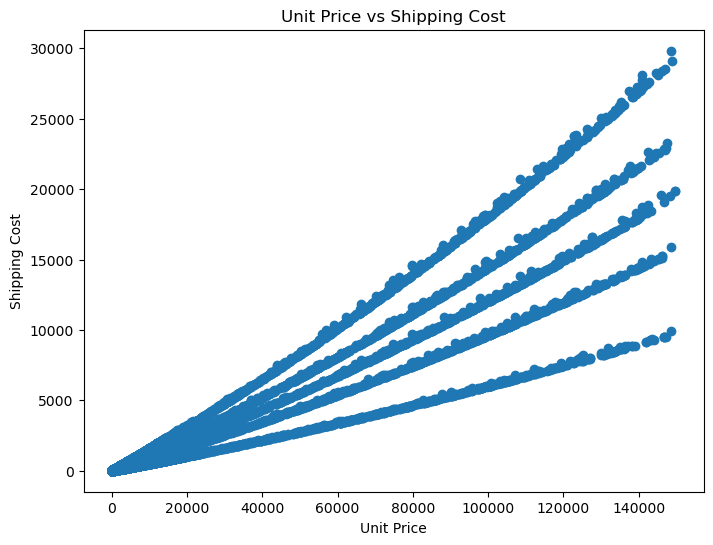

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df['unit_price'],df['shipping_cost'])
plt.xlabel("Unit Price")
plt.ylabel("Shipping Cost")
plt.title("Unit Price vs Shipping Cost")
plt.show()

In [ ]:
X = df[['unit_price']]
y = df[['shipping_cost']]

In [ ]:
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()
X_scaled = x_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y)

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X_scaled,y_scaled,test_size=0.20,random_state=42)
print(X_train.shape)
print(X_test.shape)

(120000, 1)
(30000, 1)


In [ ]:
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
print("Intercept :",model.intercept_[0])
print("Coefficient :",model.coef_[0][0])

Intercept : -0.003060117681230507
Coefficient : 0.6025506171525005


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)
print("MAE :",round(mae,5))
print("MSE :",round(mse,5))
print("RMSE :",round(rmse,5))
print("R² :",round(r2,4))

MAE : 0.00737
MSE : 0.00036
RMSE : 0.01893
R² : 0.883


In [ ]:
actual = y_scaler.inverse_transform(y_test)
predicted = y_scaler.inverse_transform(y_pred)
comparison = pd.DataFrame({
    "Actual":actual.flatten(),
    "Predicted":predicted.flatten()
})
comparison.head(10)

,Actual,Predicted
0,132.53,190.159107
1,187.62,207.764765
2,252.70,227.047151
3,250.71,467.657804
4,134.18,191.835836
5,75.12,114.706289
6,534.87,421.547749
7,759.67,575.806843
8,634.29,490.293649
9,14.41,66.919505


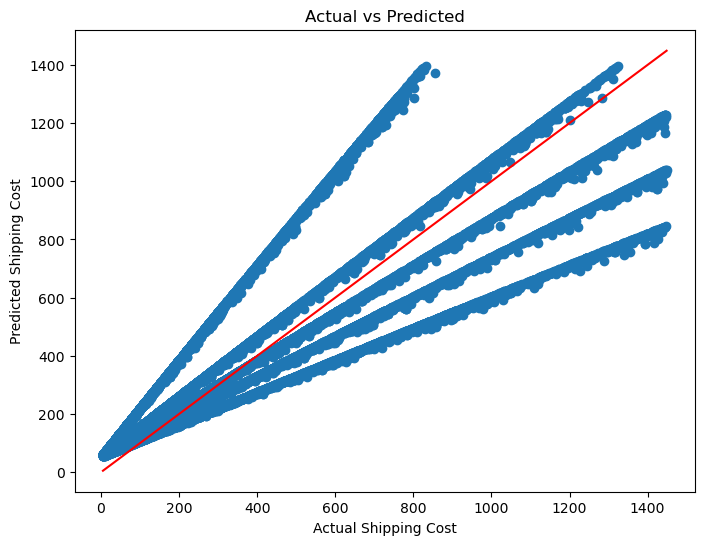

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(actual,predicted)
plt.plot(
    [actual.min(),actual.max()],
    [actual.min(),actual.max()],
    color='red'
)
plt.xlabel("Actual Shipping Cost")
plt.ylabel("Predicted Shipping Cost")
plt.title("Actual vs Predicted")
plt.show()

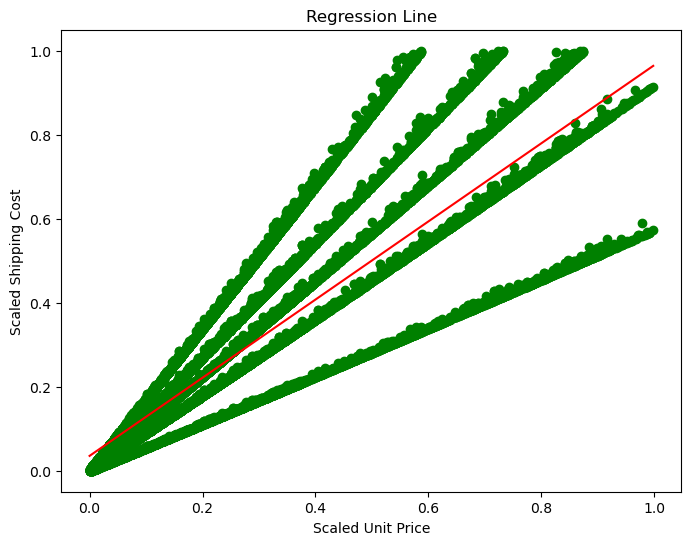

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_test,y_test,color='green')
idx = np.argsort(X_test.flatten())
plt.plot(X_test.flatten()[idx],y_pred.flatten()[idx],color='red')
plt.xlabel("Scaled Unit Price")
plt.ylabel("Scaled Shipping Cost")
plt.title("Regression Line")
plt.show()

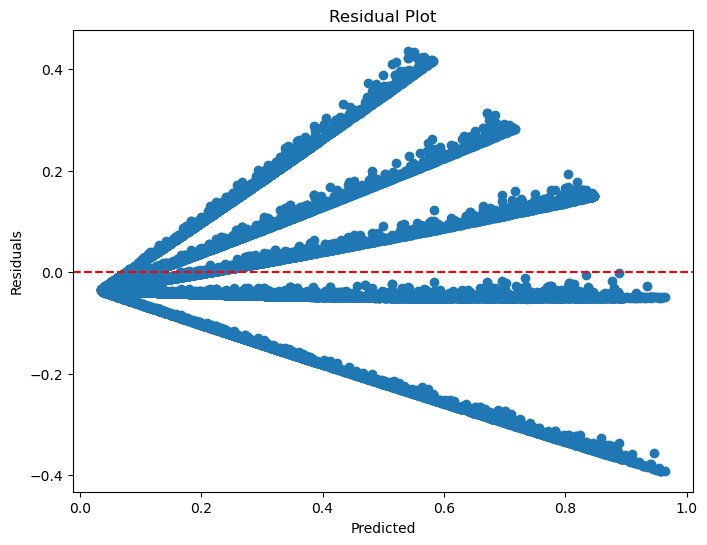

In [ ]:
residuals = y_test.flatten()-y_pred.flatten()
plt.figure(figsize=(8,6))
plt.scatter(y_pred,residuals)
plt.axhline(y=0,color='red',linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [ ]:
print("SIMPLE LINEAR REGRESSION RESULTS")
print(f"MAE : {mae:.5f}")
print(f"MSE : {mse:.5f}")
print(f"RMSE : {rmse:.5f}")
print(f"R² Score : {r2:.4f}")

if r2 >= 0.90:
    print("\nExcellent Model Fit")
elif r2 >= 0.80:
    print("\nVery Good Model Fit")
elif r2 >= 0.70:
    print("\nGood Model Fit")
else:
    print("\nModel Requires Improvement")

SIMPLE LINEAR REGRESSION RESULTS
MAE : 0.00737
MSE : 0.00036
RMSE : 0.01893
R² Score : 0.8830

Very Good Model Fit


In [ ]:
print("""
Model Interpretation

The Simple Linear Regression model was developed to predict shipping cost based on unit price. 
Before training, missing values and outliers were handled, and both the independent variable (Unit Price) 
and dependent variable (Shipping Cost) were normalized using Min-Max Scaling to improve data consistency.

The MAE (Mean Absolute Error), MSE (Mean Squared Error), and RMSE (Root Mean Squared Error) indicate the average prediction error of the model. Lower values of these metrics suggest that the predicted shipping costs are close to the actual shipping costs, demonstrating good prediction accuracy.

The R² Score indicates how well the independent variable explains the variation in the dependent variable. A higher R² value means the regression model captures the relationship between unit price and shipping cost effectively.

The regression coefficient is positive, indicating that shipping cost generally increases as unit price increases. The Actual vs Predicted plot shows that most predicted values are close to the actual values, while the Residual Plot displays residuals randomly distributed around zero, indicating that there is no significant pattern in the prediction errors.

Overall, the model demonstrates a strong linear relationship between unit price and shipping cost and can be effectively used to estimate shipping costs for future retail orders, helping businesses improve pricing strategies, logistics planning, and cost estimation.
""")


Model Interpretation

The Simple Linear Regression model was developed to predict shipping cost based on unit price. 
Before training, missing values and outliers were handled, and both the independent variable (Unit Price) 
and dependent variable (Shipping Cost) were normalized using Min-Max Scaling to improve data consistency.

The MAE (Mean Absolute Error), MSE (Mean Squared Error), and RMSE (Root Mean Squared Error) indicate the average prediction error of the model. Lower values of these metrics suggest that the predicted shipping costs are close to the actual shipping costs, demonstrating good prediction accuracy.

The R² Score indicates how well the independent variable explains the variation in the dependent variable. A higher R² value means the regression model captures the relationship between unit price and shipping cost effectively.

The regression coefficient is positive, indicating that shipping cost generally increases as unit price increases. The Actual vs Predicted pl